# **Serie de Tiempo — Total Mensual de Viajeros Internacionales**

En este notebook se construye y analiza la serie de tiempo obligatoria: el total mensual de viajeros internacionales que ingresan al país. La serie se arma a partir del conjunto de entrenamiento (`entrenamiento.csv`), que ya viene filtrado a Turista + Excursionista, sumando la cantidad de viajeros de todas las regiones, vías y fronteras por mes.

## **Setup**

In [2]:
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import boxcox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "series" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"
RUTA_TEST = RAIZ / "datos" / "processed" / "prueba.csv"
PERIODO = 12

print("Setup completado")

Setup completado


#### **a. Especifique Inicio, fin, y frecuencia.**

La serie de entrenamiento del total mensual de viajeros internacionales va desde el 1 de enero de 2009 hasta el 1 de marzo de 2021, con frecuencia mensual, es decir, cada observación representa un mes distinto, para un total de 147 observaciones. 

In [3]:
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])
serie_total = entrenamiento.groupby("Fecha")["Viajero"].sum().asfreq("MS")

print("Inicio       :", serie_total.index.min().date())
print("Fin          :", serie_total.index.max().date())
print("Frecuencia   :", serie_total.index.freqstr, "(mensual, inicio de mes)")
print("Observaciones:", serie_total.shape[0])

Inicio       : 2009-01-01
Fin          : 2021-03-01
Frecuencia   : MS (mensual, inicio de mes)
Observaciones: 147


#### **b. Gráfico de la serie.**

Tras analizar el gráfico de la serie, se evidencia una tendencia al crecimiento desde el inicio de los datos hasta el 2019. Después de esto, se pasa de un pico a un valle muy cercano a cero en cuanto a número de viajeros, lo cual se debe a la pandemia, etapa en la que no se pudo transitar libremente hacia otros países. Posterior a la pandemia, ya se evidencia en el gráfico que el turismo nuevamente iba en crecimiento, aunque de forma ligera, es decir, no con la misma fuerza ni la misma cantidad de viajeros que antes.

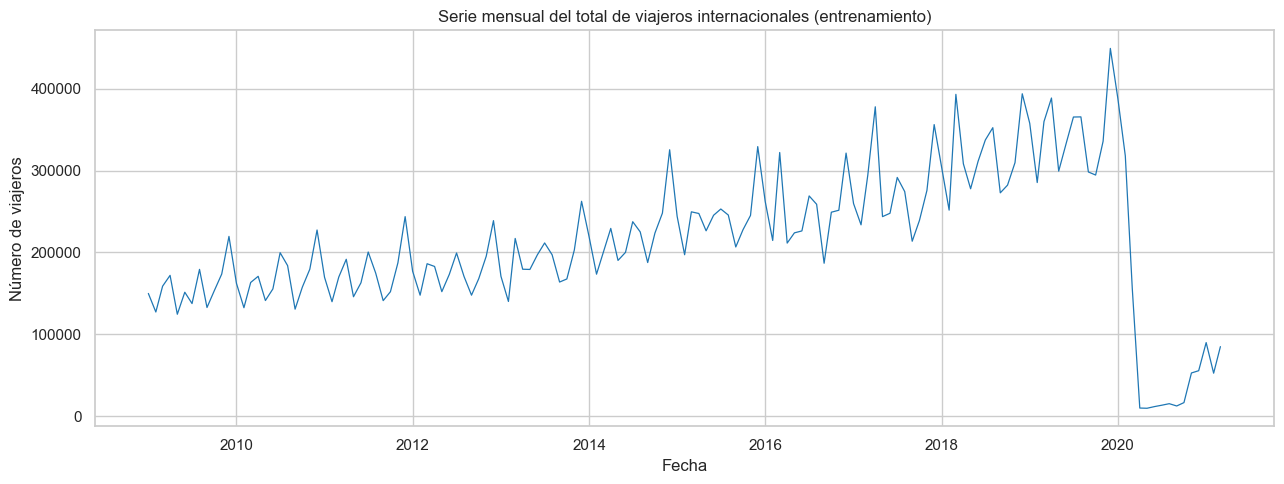

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_total.index, serie_total.values, color="tab:blue", linewidth=0.9)
ax.set_title("Serie mensual del total de viajeros internacionales (entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
plt.tight_layout()
plt.show()

#### **c. Descomponga la serie.**

Analizando los datos, se puede ver que en este caso la serie se debe manejar por medio de una descomposición multiplicativa, dado que se aprecia cómo con el tiempo va creciendo ligeramente la amplitud estacional. Esto además se respalda con el lambda de Box-Cox, que se encuentra en -0.318, un valor cercano a 0 que nos sugiere justamente que la serie se debe abordar con una descomposición multiplicativa.

Al analizar los gráficos de tendencia se nota cómo esta iba creciendo hasta llegar al punto de la pandemia, momento en el que pasa de una tendencia en crecimiento a una caída. Adicional, para respaldar esto con evidencia estadística se aplicó la prueba de Mann-Kendall, cuyo tau resultó positivo (0.42) con un p-valor prácticamente de cero, lo cual confirma que sí existe una tendencia creciente en la serie. En cuanto a la estacionalidad, se logra identificar que sí hay un patrón que se sigue, en donde se tiene un pico alto, luego otros dos picos más bajos hasta llegar a un valle, y de ahí se retoma otra vez un pico elevado.

Finalmente, en cuanto a la media móvil y la desviación móvil, se puede afirmar que ninguna de las dos es constante, especialmente por el fenómeno de la pandemia, por lo que se concluye que la serie no es estacionaria, ni en media ni en varianza.

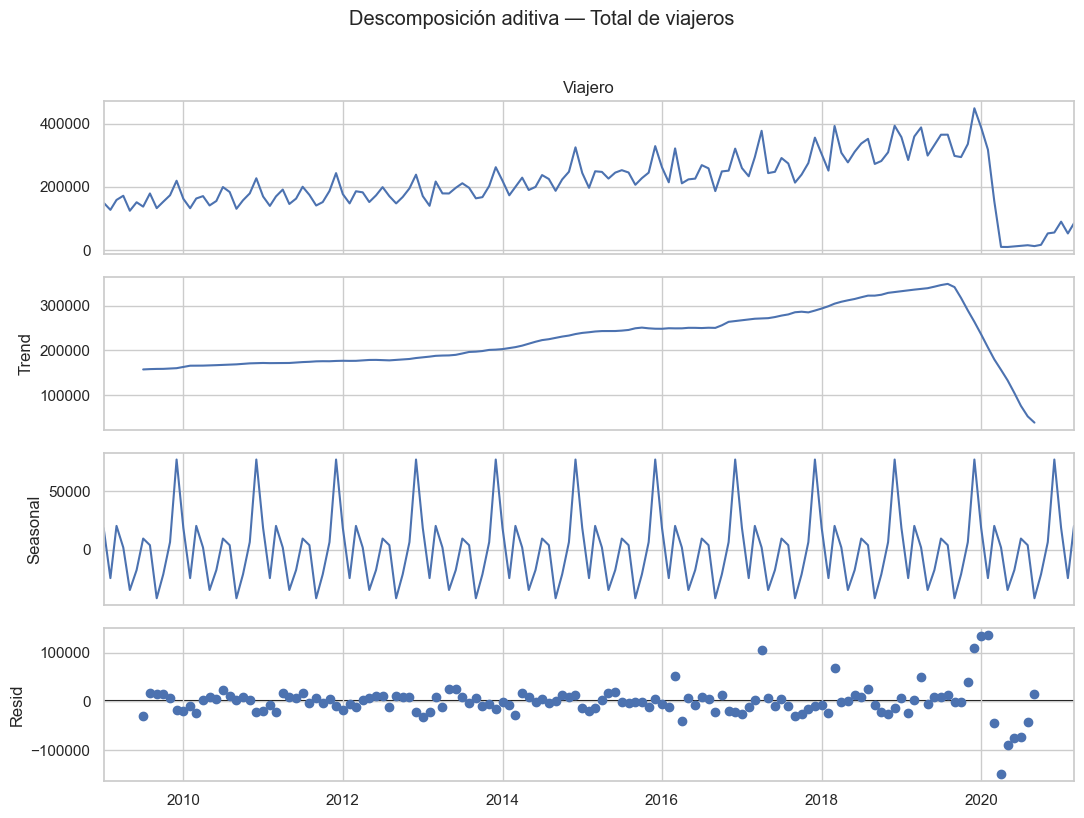

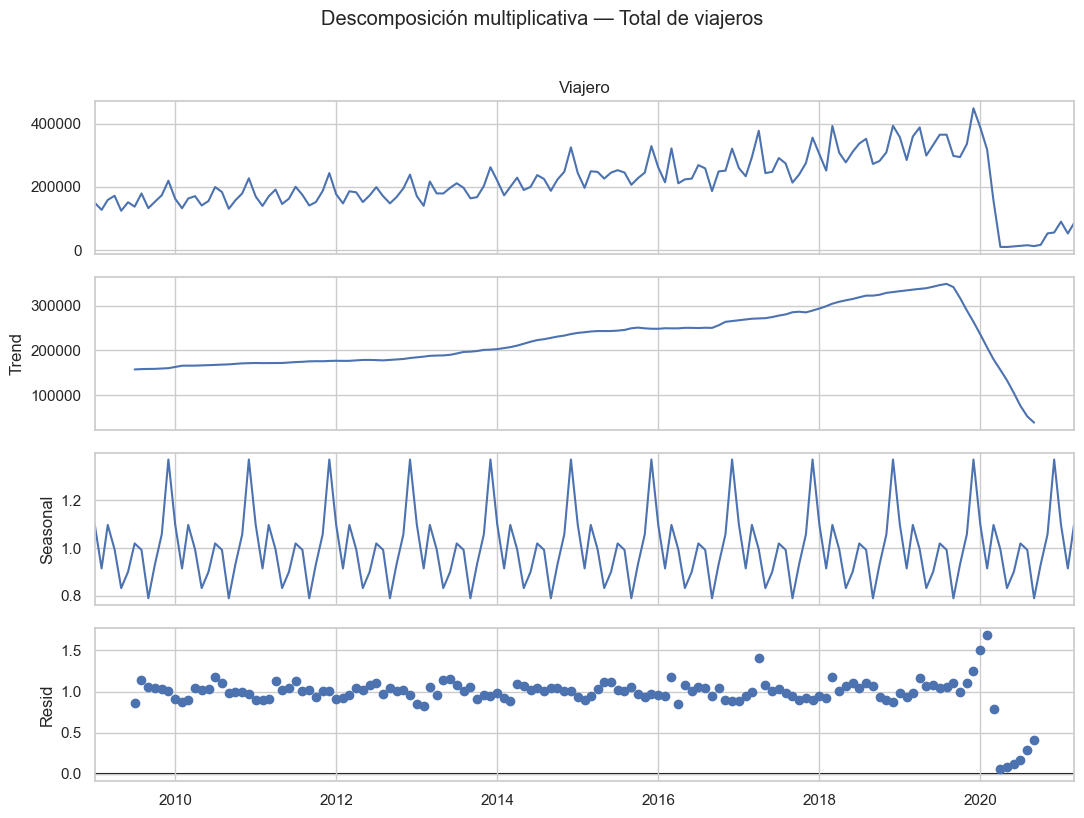

Lambda de Box-Cox (2009-2019): -0.318   (~1 aditiva, ~0 multiplicativa)
Prueba de tendencia (Mann-Kendall): tau=0.419, p-valor=5.142e-14


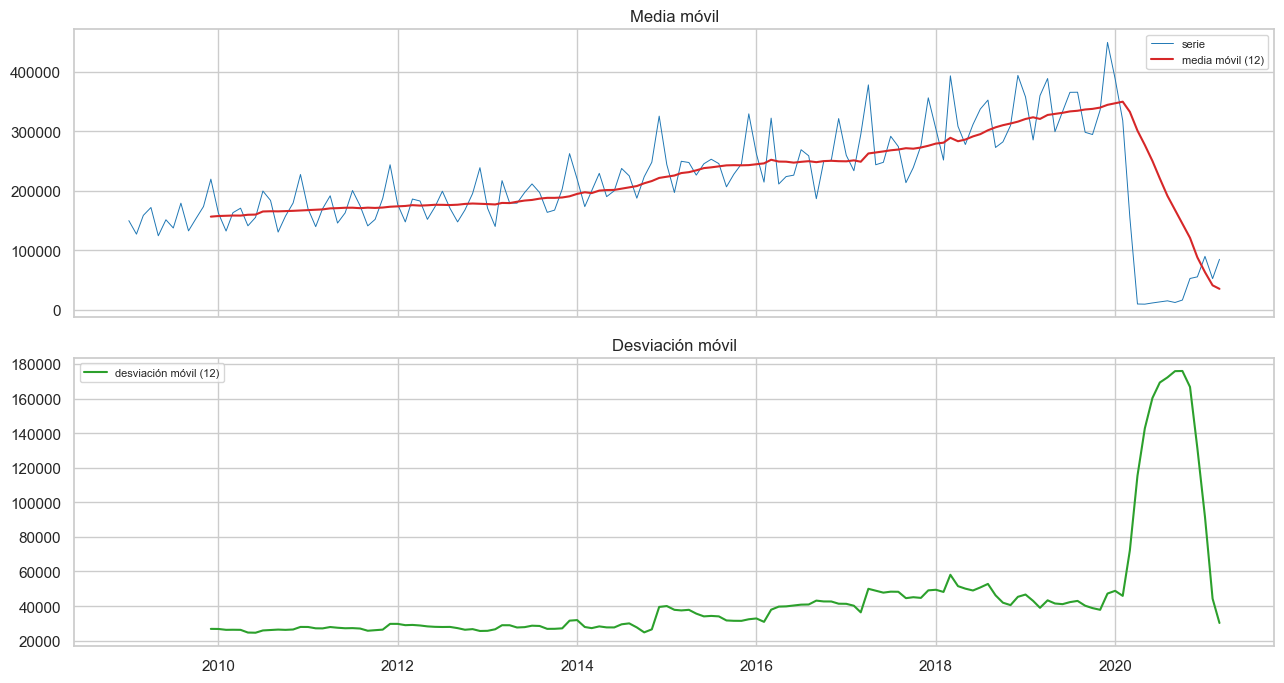

In [9]:
serie = serie_total

desc_add = seasonal_decompose(serie, model="additive", period=PERIODO)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=PERIODO)

fig = desc_add.plot(); fig.set_size_inches(11, 8); fig.suptitle("Descomposición aditiva — Total de viajeros", y=1.02)
plt.tight_layout(); plt.show()
fig = desc_mul.plot(); fig.set_size_inches(11, 8); fig.suptitle("Descomposición multiplicativa — Total de viajeros", y=1.02)
plt.tight_layout(); plt.show()

_, lambda_boxcox = boxcox(serie[serie.index < "2020-03-01"].values)
print(f"Lambda de Box-Cox (2009-2019): {lambda_boxcox:.3f}   (~1 aditiva, ~0 multiplicativa)")

from scipy.stats import kendalltau
tau_tendencia, p_tendencia = kendalltau(np.arange(len(serie)), serie.values)
print(f"Prueba de tendencia (Mann-Kendall): tau={tau_tendencia:.3f}, p-valor={p_tendencia:.4g}")

media_movil = serie.rolling(PERIODO).mean()
desv_movil = serie.rolling(PERIODO).std()
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie.index, serie.values, color="tab:blue", linewidth=0.7, label="serie")
ax[0].plot(media_movil.index, media_movil.values, color="tab:red", label="media móvil (12)")
ax[0].set_title("Media móvil"); ax[0].legend(fontsize=8)
ax[1].plot(desv_movil.index, desv_movil.values, color="tab:green", label="desviación móvil (12)")
ax[1].set_title("Desviación móvil"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### **d. Determine si es necesario transformar la serie.**

Sí se determina la necesidad de transformar la serie, ya que al evaluar el valor de Box-Cox se encuentra que este está en -0.318, un valor cercano a 0, lo cual apunta a una transformación logarítmica. Además, al hacer la prueba de tomar la serie original y aplicarle la transformación logarítmica, se encuentra que la serie original tenía un valor de 2.36 en la desviación móvil, mientras que al aplicarle el logaritmo este baja a 1.72, lo que indica que la varianza queda más estabilizada. Dado este criterio, sí es necesario transformar la serie, y la transformación elegida es la logarítmica.

Box-Cox lambda (serie completa)         : 0.991
Box-Cox lambda (2009-2019, sin pandemia): -0.318

Desviación móvil (max/min en 2009-2019; menor = más constante):
  Serie original: 2.36x
  Serie log     : 1.72x


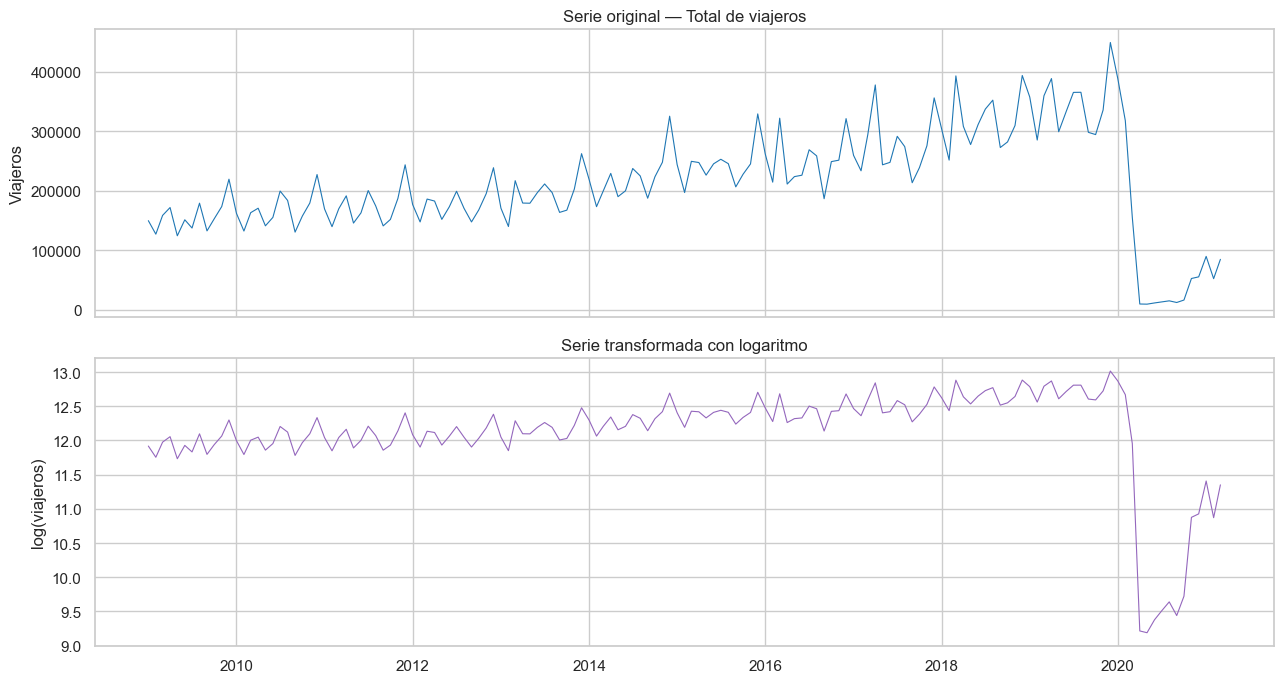

In [8]:
_, lam_full = boxcox(serie_total.values)
serie_total_pre = serie_total[serie_total.index < "2020-03-01"]
_, lam_pre = boxcox(serie_total_pre.values)
print(f"Box-Cox lambda (serie completa)         : {lam_full:.3f}")
print(f"Box-Cox lambda (2009-2019, sin pandemia): {lam_pre:.3f}")

serie_total_log = np.log(serie_total)

def ratio_desv_movil(x):
    dm = x[x.index < "2020-03-01"].rolling(PERIODO).std().dropna()
    return dm.max() / dm.min()

print(f"\nDesviación móvil (max/min en 2009-2019; menor = más constante):")
print(f"  Serie original: {ratio_desv_movil(serie_total):.2f}x")
print(f"  Serie log     : {ratio_desv_movil(serie_total_log):.2f}x")

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie_total.index, serie_total.values, color="tab:blue", linewidth=0.8)
ax[0].set_title("Serie original — Total de viajeros"); ax[0].set_ylabel("Viajeros")
ax[1].plot(serie_total_log.index, serie_total_log.values, color="tab:purple", linewidth=0.8)
ax[1].set_title("Serie transformada con logaritmo"); ax[1].set_ylabel("log(viajeros)")
plt.tight_layout(); plt.show()

#### **e. Explique si no es estacionaria en media.**

Tras realizar las pruebas se encuentra lo siguiente. Con la función de autocorrelación (ACF) se observa un decaimiento lento, lo cual ya es una señal de que la serie no es estacionaria en media. Esto se confirma con la prueba de Dickey-Fuller Aumentada (ADF): la serie sin aplicar ninguna diferenciación resulta no estacionaria. Tras aplicar la primera diferenciación se llega a un p-valor de 0.0277, dando como resultado que ahí ya se estaba en un punto estacionario, al ser menor a 0.05. Y al aplicar además una diferenciación para la parte estacional, esto nos lleva a un p-valor de prácticamente 0, llegando también a estacionario. Por lo anterior, posteriormente, cuando se llegue a entrenar el modelo, se utilizará d igual a 1 y D igual a 1.

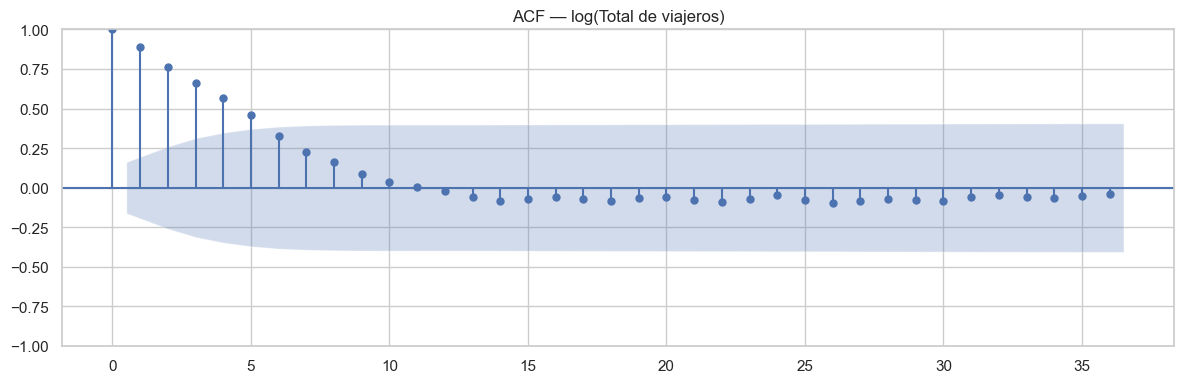

ADF log          estadístico= -2.499  p=0.1156  -> NO estacionaria
ADF log d=1      estadístico= -3.085  p=0.0277  -> estacionaria
ADF log d=1 D=1  estadístico= -6.539  p=0.0000  -> estacionaria


In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_total_log.dropna(), lags=36, ax=ax)
ax.set_title("ACF — log(Total de viajeros)")
plt.tight_layout()
plt.show()

def adf_test(x, nombre):
    r = adfuller(x.dropna(), autolag="AIC")
    print(f"ADF {nombre:12s} estadístico={r[0]:7.3f}  p={r[1]:.4f}  -> {'estacionaria' if r[1] < 0.05 else 'NO estacionaria'}")

adf_test(serie_total_log, "log")
adf_test(serie_total_log.diff(1), "log d=1")
adf_test(serie_total_log.diff(1).diff(PERIODO), "log d=1 D=1")

#### **f. Elección de los parámetros p, q y d.**

Dado que la serie presenta tendencia y estacionalidad, se trabajará con un modelo SARIMA. Retomando el inciso anterior, con una diferencia regular (d=1) se logra volver la serie estacionaria en media, y por la estacionalidad anual se agrega también una diferencia estacional (D=1, con s=12).

Para los órdenes no estacionales, ni la ACF ni la PACF muestran picos significativos en los primeros valores, por lo que p=0 y q=0. En la parte estacional, la ACF muestra un pico significativo en el mes 12 que corta después, lo cual apunta a una media móvil estacional de orden 1 (Q=1), mientras que la PACF no sugiere una parte autorregresiva estacional (P=0). Bajo esta idea, el modelo del que se parte es un SARIMA(0,1,0)(0,1,1)[12].

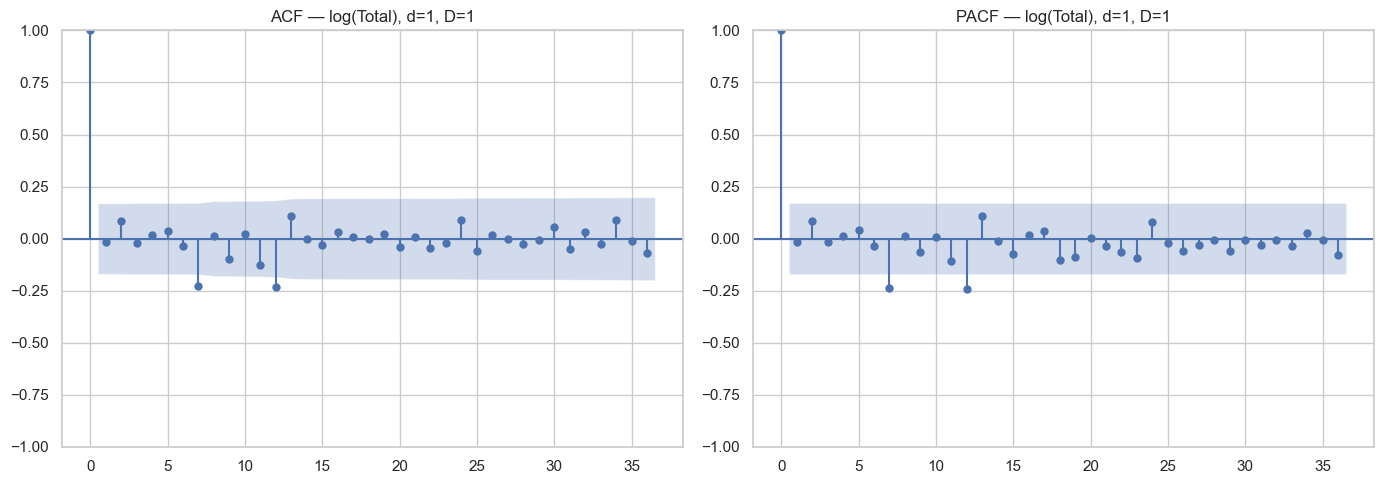

,valor
p,0
d,1
q,0
P,0
D,1
Q,1
s,12


In [11]:
s = PERIODO

d = 0
serie_tmp = serie_total_log.dropna()
while adfuller(serie_tmp)[1] >= 0.05 and d < 2:
    serie_tmp = serie_tmp.diff().dropna()
    d += 1

serie_d = serie_total_log.diff(d).dropna()
D = 1 if abs(acf(serie_d, nlags=s)[s]) > 1.96 / np.sqrt(len(serie_d)) else 0

serie_dif = serie_total_log.diff(d)
if D:
    serie_dif = serie_dif.diff(s)
serie_dif = serie_dif.dropna()

banda = 1.96 / np.sqrt(len(serie_dif))
acf_v = acf(serie_dif, nlags=2 * s)
pacf_v = pacf(serie_dif, nlags=2 * s, method="ywm")
significativo = lambda v: abs(v) > banda

def orden_corte(valores):
    orden = 0
    for k in range(1, s):
        if significativo(valores[k]):
            orden = k
        else:
            break
    return orden

p = orden_corte(pacf_v)
q = orden_corte(acf_v)

if significativo(acf_v[s]) and not significativo(acf_v[2 * s]):
    P, Q = 0, 1
elif significativo(pacf_v[s]) and not significativo(pacf_v[2 * s]):
    P, Q = 1, 0
else:
    P, Q = 0, 0

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie_dif, lags=36, ax=ax[0])
ax[0].set_title(f"ACF — log(Total), d={d}, D={D}")
plot_pacf(serie_dif, lags=36, ax=ax[1], method="ywm")
ax[1].set_title(f"PACF — log(Total), d={d}, D={D}")
plt.tight_layout()
plt.show()

parametros_sarima_total = pd.DataFrame({"valor": [p, d, q, P, D, Q, s]},
                                       index=["p", "d", "q", "P", "D", "Q", "s"])
parametros_sarima_total

#### **g. Varios modelos SARIMA y elección del mejor.**

Se ajustaron dos modelos: el Modelo 1, con los parámetros obtenidos de la ACF/PACF en el inciso f, un SARIMA(0,1,0)(0,1,1)[12], y el Modelo 2, obtenido mediante la búsqueda por AIC, que resultó ser un SARIMA(0,1,0)(1,1,0)[12].

Al analizar el AIC y el BIC se observa que el Modelo 2 es mejor que el Modelo 1 en ambas métricas, ya que por AIC obtiene 63.40 frente a 66.70, y por BIC obtiene 69.20 frente a 72.49. Cabe mencionar que ambos modelos tienen en realidad la misma cantidad de parámetros, es decir, un único término estacional cada uno, por lo que la ventaja del Modelo 2 no viene de ser más simple, sino de lograr un mejor ajuste con esa misma complejidad.

Para complementar la elección se revisaron los residuos con la prueba de Ljung-Box, cuya hipótesis nula plantea que los residuos no tienen autocorrelación, es decir, que se comportan como puro azar. En ambos modelos los p-valores resultaron mayores a 0.05 (en el Modelo 2, 0.119 y 0.750), de tal forma que a los residuos no les quedó estructura sin capturar y ambos presentan un buen ajuste.

In [12]:
modelo_1_total = SARIMAX(serie_total_log, order=(p, d, q),
                         seasonal_order=(P, D, Q, s)).fit(disp=False)
print(f"Modelo 1: SARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={modelo_1_total.aic:.2f}  BIC={modelo_1_total.bic:.2f}")

Modelo 1: SARIMA(0,1,0)(0,1,1)[12]  AIC=66.70  BIC=72.49


In [13]:
mejor_total = {"aic": np.inf, "order": None, "seasonal_order": None}
for pp, qq, PP, QQ in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(serie_total_log, order=(pp, d, qq),
                    seasonal_order=(PP, D, QQ, s)).fit(disp=False)
        if m.aic < mejor_total["aic"]:
            mejor_total = {"aic": m.aic, "order": (pp, d, qq), "seasonal_order": (PP, D, QQ, s)}
    except Exception:
        continue

modelo_2_total = SARIMAX(serie_total_log, order=mejor_total["order"],
                         seasonal_order=mejor_total["seasonal_order"]).fit(disp=False)
print("Mejor orden por AIC:", mejor_total["order"], mejor_total["seasonal_order"])
print(f"Modelo 2: AIC={modelo_2_total.aic:.2f}  BIC={modelo_2_total.bic:.2f}")

Mejor orden por AIC: (0, 1, 0) (1, 1, 0, 12)
Modelo 2: AIC=63.40  BIC=69.20


,AIC,BIC
Modelo 1 (ACF/PACF),66.7,72.49
Modelo 2 (búsqueda AIC),63.4,69.20


Modelo 1 — Ljung-Box p-valores: lag 12 = 0.139, lag 24 = 0.764
Modelo 2 — Ljung-Box p-valores: lag 12 = 0.119, lag 24 = 0.750


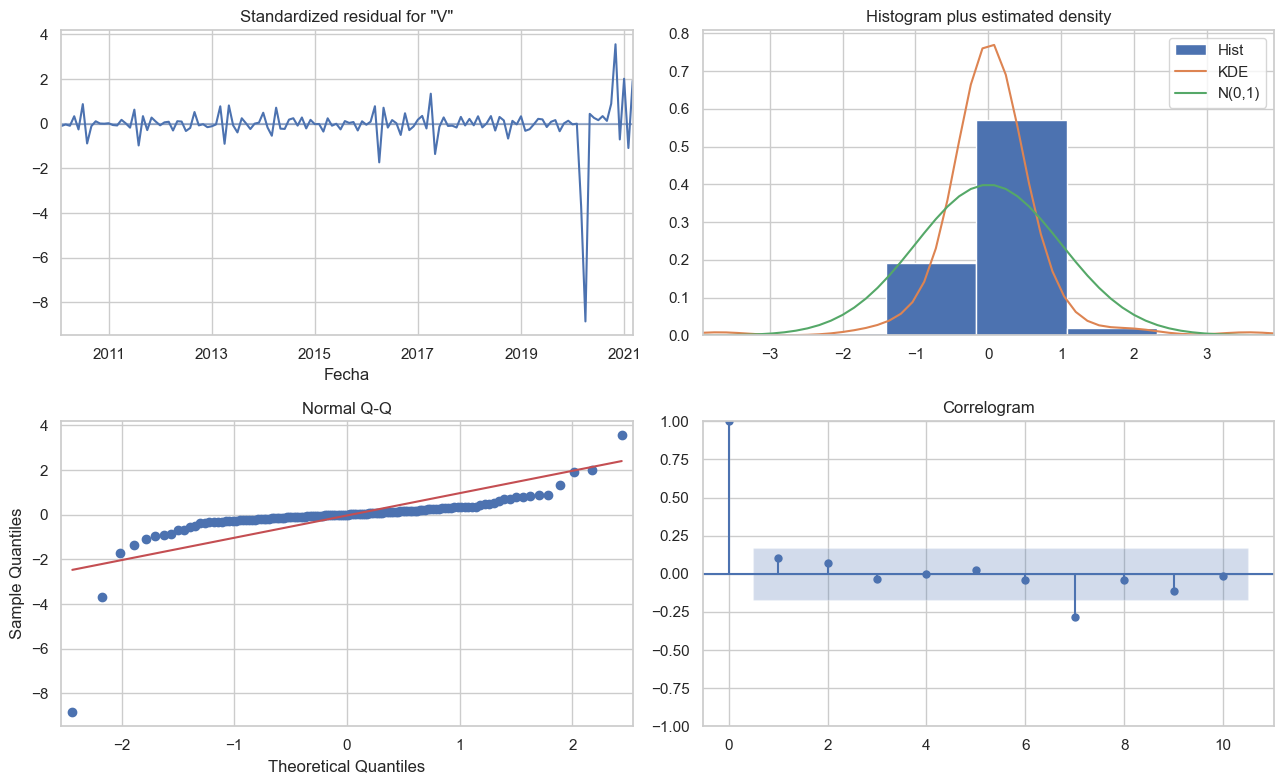

In [14]:
comparacion_total = pd.DataFrame({
    "AIC": [modelo_1_total.aic, modelo_2_total.aic],
    "BIC": [modelo_1_total.bic, modelo_2_total.bic],
}, index=["Modelo 1 (ACF/PACF)", "Modelo 2 (búsqueda AIC)"]).round(2)
display(comparacion_total)

burn = d + s * D
for nombre, modelo in [("Modelo 1", modelo_1_total), ("Modelo 2", modelo_2_total)]:
    resid = pd.Series(modelo.standardized_forecasts_error[0], index=serie_total_log.index).iloc[burn:]
    lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    print(f"{nombre} — Ljung-Box p-valores: lag 12 = {lb['lb_pvalue'].iloc[0]:.3f}, lag 24 = {lb['lb_pvalue'].iloc[1]:.3f}")

modelo_2_total.plot_diagnostics(figsize=(13, 8))
plt.tight_layout(); plt.show()

#### **h. Otros modelos y comparación.**

Para determinar el mejor modelo entre todos los entrenados se utilizaron el MAE y el RMSE sobre el conjunto de prueba. El mejor resultó ser el de suavizamiento exponencial simple, con un MAE de alrededor de 158,777 y un RMSE de 173,709, quedando por encima de Holt-Winters, del seasonal naive, del SARIMA y de Prophet. Esto se puede deber a que el conjunto de entrenamiento termina justo en el desplome de la pandemia, lo que hace que los modelos que se enfocan en aprender la tendencia proyecten esa caída hacia adelante, mientras que un modelo más simple se mantiene en un nivel más estable y por eso se acerca más a los valores reales del período de prueba.

Importing plotly failed. Interactive plots will not work.
14:48:39 - cmdstanpy - INFO - Chain [1] start processing
14:48:39 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE
Suav. exp. simple,158777.0,173709.0
Holt-Winters,178392.0,192825.0
Seasonal naive,207322.0,219664.0
SARIMA (Modelo 2),228181.0,244059.0
Prophet,233092.0,246956.0


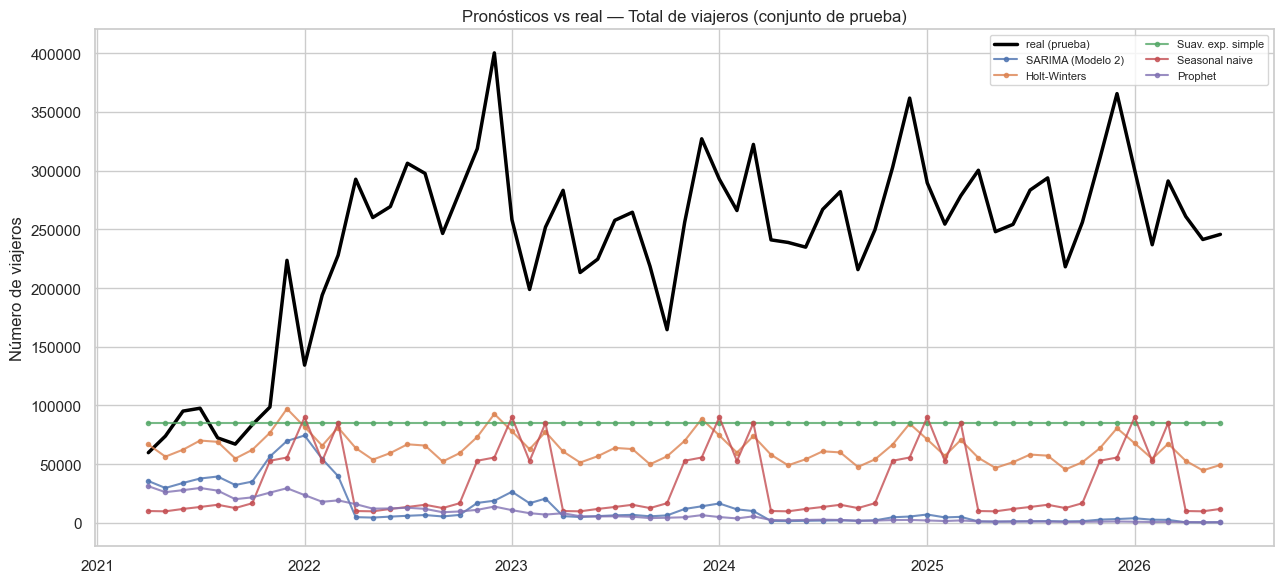

In [15]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
from prophet import Prophet

prueba = pd.read_csv(RUTA_TEST, parse_dates=["Fecha"])
serie_test_total = prueba.groupby("Fecha")["Viajero"].sum().asfreq("MS")
serie_test_log_total = np.log(serie_test_total)
H_total = len(serie_test_log_total)

def metricas(y_true_log, y_pred_log):
    y_true, y_pred = np.exp(y_true_log), np.exp(np.asarray(y_pred_log))
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

hw_total = ExponentialSmoothing(serie_total_log, trend="add", seasonal="add", seasonal_periods=s).fit()
ses_total = SimpleExpSmoothing(serie_total_log).fit()

df_prophet_total = pd.DataFrame({"ds": serie_total_log.index, "y": serie_total_log.values})
modelo_prophet_total = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet_total.fit(df_prophet_total)
pred_prophet_total = modelo_prophet_total.predict(pd.DataFrame({"ds": serie_test_log_total.index})).set_index("ds")["yhat"]

pronosticos_total = {
    "SARIMA (Modelo 2)": modelo_2_total.get_forecast(H_total).predicted_mean,
    "Holt-Winters": hw_total.forecast(H_total),
    "Suav. exp. simple": ses_total.forecast(H_total),
    "Seasonal naive": pd.Series(np.tile(serie_total_log.iloc[-s:].values, int(np.ceil(H_total / s)))[:H_total],
                                index=serie_test_log_total.index),
    "Prophet": pred_prophet_total,
}

comparacion_h_total = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas(serie_test_log_total.values, p.values))) for nombre, p in pronosticos_total.items()}
).T.round(0).sort_values("RMSE")
display(comparacion_h_total)

real_total = np.exp(serie_test_log_total)
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(real_total.index, real_total.values, color="black", linewidth=2.5, label="real (prueba)")
for nombre, p in pronosticos_total.items():
    ax.plot(p.index, np.exp(np.asarray(p.values)), marker=".", alpha=0.8, label=nombre)
ax.set_title("Pronósticos vs real — Total de viajeros (conjunto de prueba)")
ax.set_ylabel("Número de viajeros")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

#### **i. Predicción con el mejor modelo.**

Con el mejor modelo, el suavizamiento exponencial simple, se proyectaron los valores de la serie hasta el año 2027. El comportamiento descrito por la predicción es prácticamente plano, con un nivel de alrededor de 1,020,209 viajeros al año para todos los años, mientras que en la realidad los años posteriores a la pandemia rondaron los 3 millones, con 3,229,329 en 2022 y 3,352,289 en 2025. Bajo esta idea, la predicción se queda corta frente a la recuperación real, ya que el modelo simplemente extiende el último nivel deprimido del entrenamiento y no logra capturar el crecimiento. Para el año 2027 predice nuevamente alrededor de 1,020,209 viajeros, cifra que muy probablemente subestima el comportamiento real, dado que el turismo ya se encuentra recuperado en niveles cercanos a los 3 millones anuales.

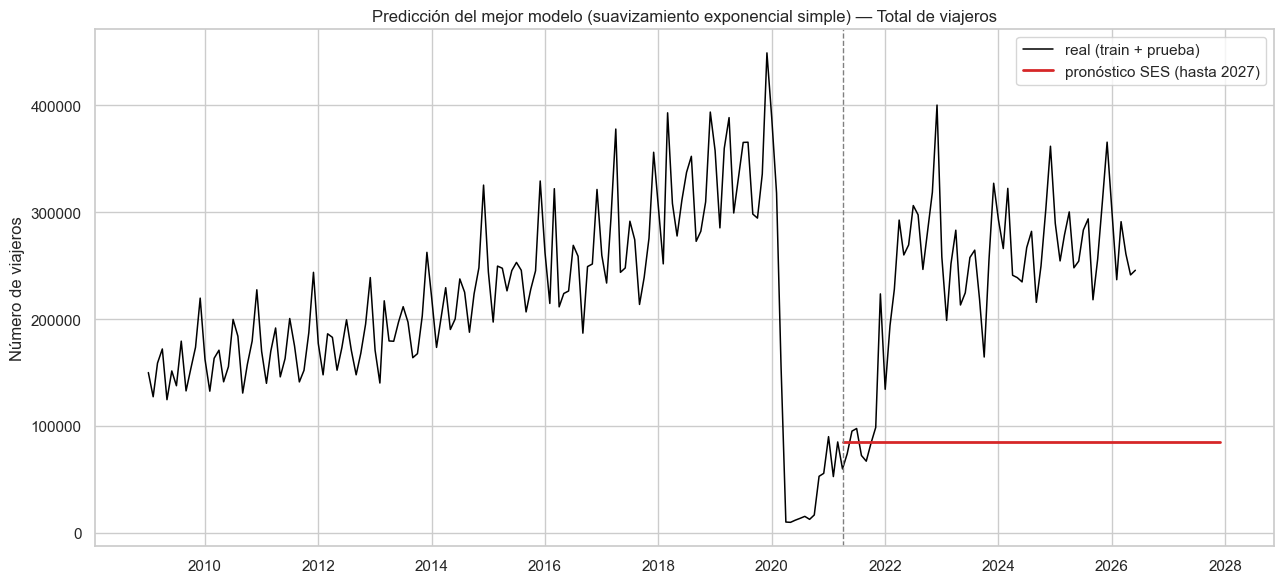

,real,predicho_SES
2022,3229329.0,1020209.0
2023,2917827.0,1020209.0
2024,3274436.0,1020209.0
2025,3352289.0,1020209.0
2026,1576619.0,1020209.0
2027,NaN,1020209.0


In [16]:
serie_real_total = pd.concat([np.exp(serie_total_log), np.exp(serie_test_log_total)])
indice_futuro_total = pd.date_range("2021-04-01", "2027-12-01", freq="MS")
pronostico_ses_total = np.exp(pd.Series(ses_total.forecast(len(indice_futuro_total)).values, index=indice_futuro_total))

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real_total.index, serie_real_total.values, color="black", linewidth=1.1, label="real (train + prueba)")
ax.plot(pronostico_ses_total.index, pronostico_ses_total.values, color="tab:red", linewidth=2, label="pronóstico SES (hasta 2027)")
ax.axvline(pd.Timestamp("2021-04-01"), color="gray", linestyle="--", linewidth=1)
ax.set_title("Predicción del mejor modelo (suavizamiento exponencial simple) — Total de viajeros")
ax.set_ylabel("Número de viajeros")
ax.legend()
plt.tight_layout(); plt.show()

totales_anuales_total = pd.DataFrame({
    "real": serie_real_total.groupby(serie_real_total.index.year).sum(),
    "predicho_SES": pronostico_ses_total.groupby(pronostico_ses_total.index.year).sum(),
}).loc[[2022, 2023, 2024, 2025, 2026, 2027]].round(0)
display(totales_anuales_total)

#### **j. Comparación de modelos por métricas.**

En esta sección se consolidan las métricas en dos tablas: la primera con el MAE y el RMSE de todos los modelos, incluyendo ambos SARIMA, y la segunda con el AIC y el BIC de esos dos SARIMA. Cabe mencionar que estas métricas ya se discutieron previamente: el AIC y el BIC en el inciso g, donde el Modelo 2 resultó mejor que el Modelo 1, y el MAE y el RMSE en el inciso h, donde el suavizamiento exponencial simple resultó el mejor de todos y los modelos SARIMA quedaron en el fondo.

In [17]:
pronosticos_j_total = dict(pronosticos_total)
pronosticos_j_total["SARIMA (Modelo 1)"] = modelo_1_total.get_forecast(H_total).predicted_mean
tabla_errores_total = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas(serie_test_log_total.values, p.values))) for nombre, p in pronosticos_j_total.items()}
).T.round(0).sort_values("RMSE")
display(tabla_errores_total)

tabla_ic_total = pd.DataFrame({
    "AIC": [modelo_1_total.aic, modelo_2_total.aic],
    "BIC": [modelo_1_total.bic, modelo_2_total.bic],
}, index=["SARIMA (Modelo 1)", "SARIMA (Modelo 2)"]).round(2)
display(tabla_ic_total)

,MAE,RMSE
Suav. exp. simple,158777.0,173709.0
Holt-Winters,178392.0,192825.0
Seasonal naive,207322.0,219664.0
SARIMA (Modelo 1),219512.0,234055.0
SARIMA (Modelo 2),228181.0,244059.0
Prophet,233092.0,246956.0


,AIC,BIC
SARIMA (Modelo 1),66.7,72.49
SARIMA (Modelo 2),63.4,69.20


#### **k. Selección del mejor modelo.**

Con base en las métricas del inciso j, el mejor modelo para esta serie fue el de suavizamiento exponencial simple, con un MAE de 158,777 y un RMSE de 173,709, por encima de ambos SARIMA y de los demás modelos. Esto probablemente se debe a que la pandemia dentro del conjunto de entrenamiento afecta más a los modelos que se enfocan en aprender la tendencia, ya que terminan proyectando hacia adelante el desplome con el que cierra el entrenamiento.